<a href="https://colab.research.google.com/github/2303A51553/HPC/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from multiprocessing import Pool, cpu_count
from PIL import Image, ImageFilter, ImageEnhance

print(f"✅ Libraries loaded successfully")
print(f"🖥️  CPU cores available: {cpu_count()}")

✅ Libraries loaded successfully
🖥️  CPU cores available: 2


✅ Generated 50 synthetic 512×512 RGB images in 'processed_images/'


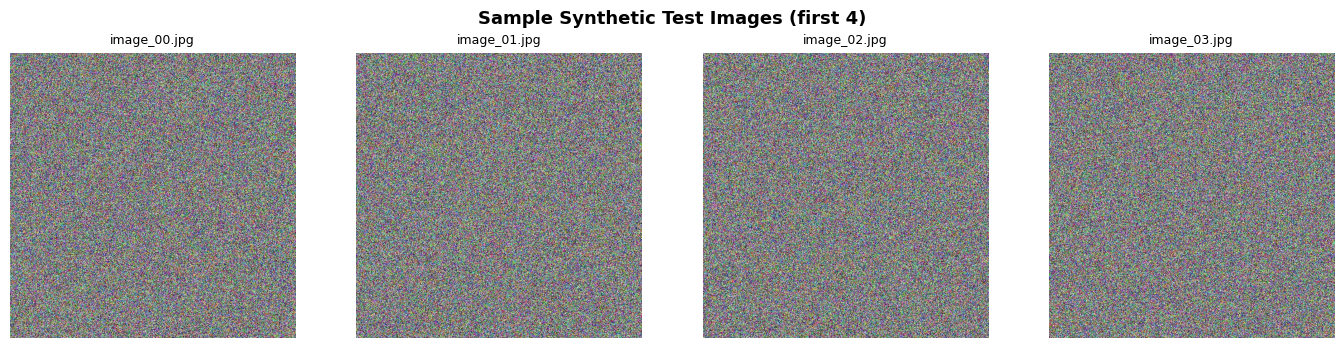

In [2]:
OUTPUT_DIR = 'processed_images'
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_IMAGES = 50   # Change this to test different batch sizes

image_paths = []
for i in range(NUM_IMAGES):
    arr = np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8)
    path = os.path.join(OUTPUT_DIR, f'image_{i:02d}.jpg')
    Image.fromarray(arr).save(path)
    image_paths.append(path)

print(f"✅ Generated {NUM_IMAGES} synthetic 512×512 RGB images in '{OUTPUT_DIR}/'")

# Preview first 4 images
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.suptitle('Sample Synthetic Test Images (first 4)', fontsize=13, fontweight='bold')
for idx, ax in enumerate(axes):
    img = Image.open(image_paths[idx])
    ax.imshow(img)
    ax.set_title(f'image_{idx:02d}.jpg', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# Four filters applied to every image
FILTERS = {
    'Grayscale':   lambda img: img.convert('L'),
    'Blur':        lambda img: img.filter(ImageFilter.BLUR),
    'Sharpen':     lambda img: img.filter(ImageFilter.SHARPEN),
    'Brightness':  lambda img: ImageEnhance.Brightness(img).enhance(1.5),
}

def process_image(path):
    """Open one image, apply all 4 filters, return results with per-filter timing."""
    img = Image.open(path)
    results = {}
    for name, func in FILTERS.items():
        t0 = time.perf_counter()
        results[name] = func(img.copy())
        results[name + '_time'] = time.perf_counter() - t0
    return results

print("✅ Filters defined:")
for name in FILTERS:
    print(f"   • {name}")

✅ Filters defined:
   • Grayscale
   • Blur
   • Sharpen
   • Brightness


In [4]:
print("⏳ Running sequential processing...")

t0 = time.time()
seq_results = [process_image(p) for p in image_paths]
seq_time = time.time() - t0

print(f"✅ Sequential time : {seq_time:.4f} seconds")

# Per-filter average times
print("\n📊 Average time per filter (sequential):")
for name in FILTERS:
    avg = sum(r[name + '_time'] for r in seq_results) / len(seq_results) * 1000
    print(f"   {name:<12}: {avg:.2f} ms/image")

⏳ Running sequential processing...
✅ Sequential time : 1.4760 seconds

📊 Average time per filter (sequential):
   Grayscale   : 2.60 ms/image
   Blur        : 13.24 ms/image
   Sharpen     : 7.84 ms/image
   Brightness  : 5.54 ms/image


In [5]:
import multiprocessing
# Colab uses 'fork' by default on Linux — no need to set start method

print(f"⏳ Running parallel processing ({cpu_count()} cores)...")

t0 = time.time()
with Pool(cpu_count()) as pool:
    par_results = pool.map(process_image, image_paths)
par_time = time.time() - t0

speedup = seq_time / par_time

print(f"✅ Parallel time   : {par_time:.4f} seconds")
print(f"🚀 Speedup         : {speedup:.2f}x  (cores used: {cpu_count()})")

if speedup >= 1.0:
    print("\n✅ Parallel is FASTER — workload is large enough to amortise spawn overhead.")
else:
    print("\n⚠️  Parallel is SLOWER — process-spawning overhead dominates at this batch size.")
    print("   Try increasing NUM_IMAGES to 20 or 50 for a genuine speedup.")

⏳ Running parallel processing (2 cores)...
✅ Parallel time   : 1.5117 seconds
🚀 Speedup         : 0.98x  (cores used: 2)

⚠️  Parallel is SLOWER — process-spawning overhead dominates at this batch size.
   Try increasing NUM_IMAGES to 20 or 50 for a genuine speedup.


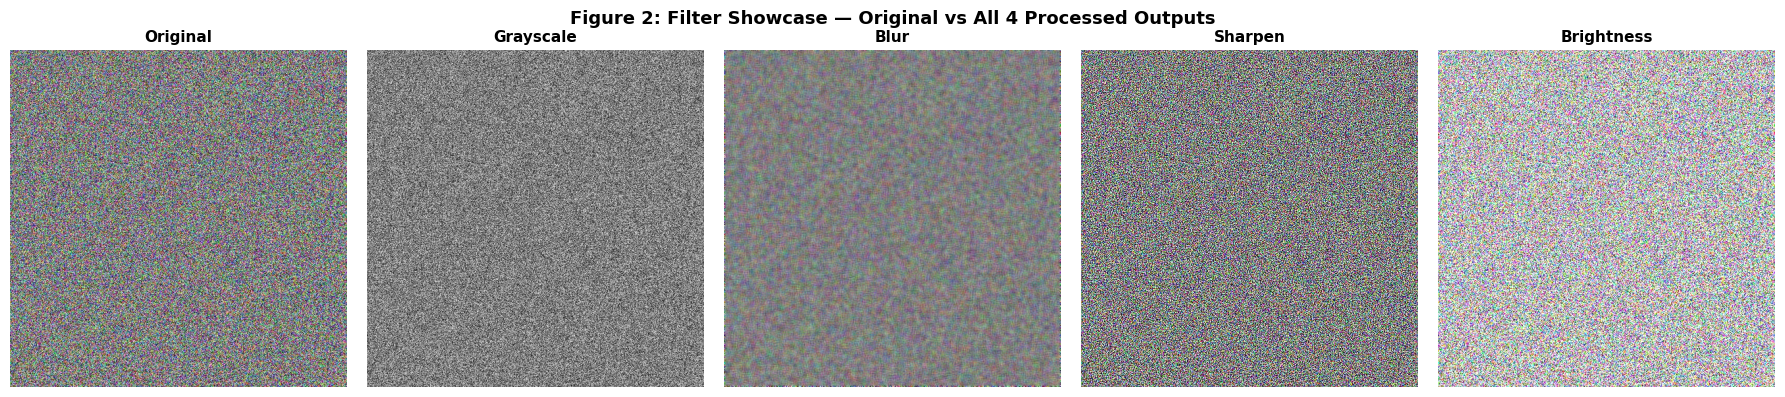

✅ Saved: processed_images/filter_showcase.png


In [6]:
original = Image.open(image_paths[0])
filter_outputs = {
    'Original':    original,
    'Grayscale':   original.convert('L'),
    'Blur':        original.filter(ImageFilter.BLUR),
    'Sharpen':     original.filter(ImageFilter.SHARPEN),
    'Brightness':  ImageEnhance.Brightness(original).enhance(1.5),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Figure 2: Filter Showcase — Original vs All 4 Processed Outputs',
             fontsize=13, fontweight='bold')

cmaps = [None, 'gray', None, None, None]
for ax, (title, img), cmap in zip(axes, filter_outputs.items(), cmaps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'filter_showcase.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: processed_images/filter_showcase.png")

In [7]:
print(f"💾 Saving sample outputs from first image...")
for name, img in par_results[0].items():
    if isinstance(img, Image.Image):
        out_path = os.path.join(OUTPUT_DIR, f'sample_{name}.png')
        img.save(out_path)
        print(f"   Saved: sample_{name}.png")
print("\n✅ All sample outputs saved.")

💾 Saving sample outputs from first image...
   Saved: sample_Grayscale.png
   Saved: sample_Blur.png
   Saved: sample_Sharpen.png
   Saved: sample_Brightness.png

✅ All sample outputs saved.


In [8]:
batch_sizes = [4, 8, 20, 50]
seq_times_list = []
par_times_list = []
speedups_list  = []

print(f"{'Batch':>6} | {'Seq (s)':>9} | {'Par (s)':>9} | {'Speedup':>9} | Interpretation")
print("-" * 65)

for batch in batch_sizes:
    paths = image_paths[:batch]

    t0 = time.time()
    [process_image(p) for p in paths]
    s = time.time() - t0
    seq_times_list.append(s)

    t0 = time.time()
    with Pool(cpu_count()) as pool:
        pool.map(process_image, paths)
    p_t = time.time() - t0
    par_times_list.append(p_t)

    sp = s / p_t
    speedups_list.append(sp)

    note = "overhead dominates" if sp < 1.0 else ("break-even" if sp < 1.3 else "real speedup ✅")
    print(f"{batch:>6} | {s:>9.3f} | {p_t:>9.3f} | {sp:>8.2f}x | {note}")

 Batch |   Seq (s) |   Par (s) |   Speedup | Interpretation
-----------------------------------------------------------------
     4 |     0.120 |     0.160 |     0.75x | overhead dominates
     8 |     0.236 |     0.270 |     0.87x | overhead dominates
    20 |     0.596 |     0.620 |     0.96x | overhead dominates
    50 |     1.450 |     1.422 |     1.02x | break-even
